# Spam Detection — Multinomial Naive Bayes
### Detectron AI · Module 02

This notebook trains a real **Multinomial Naive Bayes** classifier on a labeled
SMS/email corpus to distinguish spam from legitimate ("ham") messages. The same
algorithm (re-implemented in JavaScript) powers the live demo in the Detectron AI
web console.

**Pipeline:** raw text → CountVectorizer (bag-of-words) → MultinomialNB → prediction


In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt


## 1. Training data

A small labeled seed corpus (spam=1, ham=0). In production this would be the SMS Spam Collection or Enron-Spam dataset.

In [2]:
data = [
    ("win free money now click here", 1),
    ("congratulations you won a lottery claim your prize", 1),
    ("urgent your account has been suspended verify now", 1),
    ("limited time offer buy now discount 90 percent", 1),
    ("click this link to claim your free gift card", 1),
    ("you have been selected for a cash reward act now", 1),
    ("hot singles in your area click to chat", 1),
    ("make money fast work from home guaranteed income", 1),
    ("your loan has been approved click to receive funds", 1),
    ("free iphone giveaway claim yours today limited stock", 1),
    ("nigerian prince needs your help transfer million dollars", 1),
    ("lowest price viagra cialis no prescription needed", 1),
    ("act now offer expires today dont miss out", 1),
    ("congratulations winner claim prize within 24 hours", 1),
    ("increase your credit score instantly call now", 1),
    ("you are pre approved for a credit card apply now", 1),
    ("weight loss pills lose 10 kg in a week guaranteed", 1),
    ("earn bitcoin fast investment opportunity click here", 1),
    ("free trial no credit card required claim now", 1),
    ("your package could not be delivered click to reschedule", 1),
    ("alert unusual activity detected verify your identity now", 1),
    ("exclusive deal only for you click before midnight", 1),
    ("double your investment in 24 hours guaranteed returns", 1),
    ("claim your inheritance from unknown relative now", 1),
    ("this is not a scam send your bank details to claim", 1),
    ("hey are we still meeting for lunch tomorrow", 0),
    ("please find attached the report you requested", 0),
    ("can you send me the notes from yesterdays class", 0),
    ("happy birthday hope you have a wonderful day", 0),
    ("the meeting has been rescheduled to 3pm friday", 0),
    ("thanks for your help with the project today", 0),
    ("lets catch up over coffee this weekend", 0),
    ("i finished the assignment can you review it", 0),
    ("reminder your dentist appointment is tomorrow morning", 0),
    ("the train was delayed so i will be late", 0),
    ("could you share the slides from todays presentation", 0),
    ("mom called and said dinner is at seven", 0),
    ("here is the invoice for last months service", 0),
    ("see you at the gym later this evening", 0),
    ("just checking in on how the project is going", 0),
    ("the package arrived safely thank you for ordering", 0),
    ("lets plan the trip itinerary this weekend", 0),
    ("your order has shipped and will arrive friday", 0),
    ("i added comments to the document please review", 0),
    ("can we move our call to tomorrow morning", 0),
    ("the quarterly report is due next monday", 0),
    ("loved the photos from your trip looked amazing", 0),
    ("dont forget to bring your laptop to the meeting", 0),
    ("the weather looks great for the weekend hike", 0),
    ("attached is the contract for your review and signature", 0),
]

df = pd.DataFrame(data, columns=["text", "label"])
df["label_name"] = df["label"].map({1: "spam", 0: "ham"})
df.head()


,text,label,label_name
0,win free money now click here,1,spam
1,congratulations you won a lottery claim your p...,1,spam
2,urgent your account has been suspended verify now,1,spam
3,limited time offer buy now discount 90 percent,1,spam
4,click this link to claim your free gift card,1,spam


label_name
spam    25
ham     25
Name: count, dtype: int64


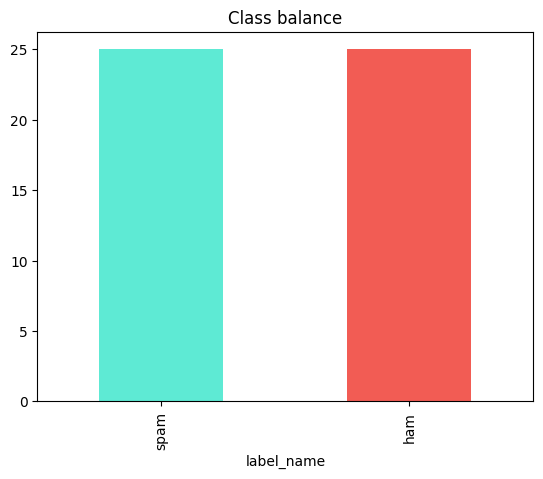

In [3]:
print(df["label_name"].value_counts())
df["label_name"].value_counts().plot(kind="bar", color=["#5EEAD4", "#F25C54"])
plt.title("Class balance")
plt.show()


## 2. Vectorize text and split data

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label"], test_size=0.25, random_state=42, stratify=df["label"]
)

vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Vocabulary size:", len(vectorizer.vocabulary_))
print("Train samples:", X_train_vec.shape[0], "| Test samples:", X_test_vec.shape[0])


Vocabulary size: 179
Train samples: 37 | Test samples: 13


## 3. Train Multinomial Naive Bayes

In [5]:
model = MultinomialNB(alpha=1.0)  # alpha=1.0 -> Laplace smoothing
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)
acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc:.2%}")
print()
print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))


Test accuracy: 92.31%



              precision    recall  f1-score   support

         ham       0.88      1.00      0.93         7
        spam       1.00      0.83      0.91         6

    accuracy                           0.92        13
   macro avg       0.94      0.92      0.92        13
weighted avg       0.93      0.92      0.92        13



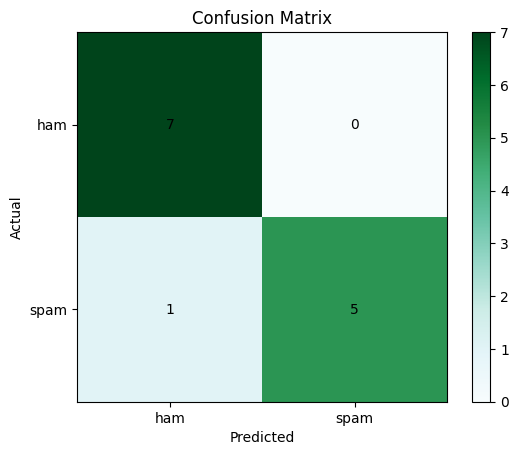

In [6]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots()
im = ax.imshow(cm, cmap="BuGn")
ax.set_xticks([0, 1]); ax.set_xticklabels(["ham", "spam"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["ham", "spam"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center")
plt.title("Confusion Matrix")
plt.colorbar(im)
plt.show()


## 4. Inspect most informative words

Which words push a message toward spam vs. ham?

In [7]:
feature_names = np.array(vectorizer.get_feature_names_out())
log_prob_diff = model.feature_log_prob_[1] - model.feature_log_prob_[0]  # spam - ham
top_spam_idx = np.argsort(log_prob_diff)[-15:][::-1]
top_ham_idx = np.argsort(log_prob_diff)[:15]

print("Top spam-indicating words:")
print(feature_names[top_spam_idx])
print()
print("Top ham-indicating words:")
print(feature_names[top_ham_idx])


Top spam-indicating words:
['now' 'click' 'claim' 'free' 'in' 'investment' 'guaranteed' '24' 'card'
 'fast' 'credit' 'money' 'offer' 'prize' 'hours']

Top ham-indicating words:
['the' 'is' 'meeting' 'and' 'for' 'friday' 'attached' 'at' 'weekend'
 'trip' 'tomorrow' 'will' 'called' 'bring' 'class']


## 5. Try your own message

In [8]:
def predict_message(text):
    vec = vectorizer.transform([text])
    pred = model.predict(vec)[0]
    proba = model.predict_proba(vec)[0]
    label = "SPAM" if pred == 1 else "HAM"
    print(f"Message: {text!r}")
    print(f"Prediction: {label}  (P(spam)={proba[1]:.3f}, P(ham)={proba[0]:.3f})")

predict_message("Congratulations! You've been selected to win a free vacation, click now!")
predict_message("Can you send me the slides from today's meeting?")


Message: "Congratulations! You've been selected to win a free vacation, click now!"
Prediction: SPAM  (P(spam)=1.000, P(ham)=0.000)
Message: "Can you send me the slides from today's meeting?"
Prediction: HAM  (P(spam)=0.001, P(ham)=0.999)


## Notes

- This is the same algorithm (Multinomial Naive Bayes with Laplace smoothing) used in the
  browser-based live demo on the Detectron AI website — that version is hand-implemented in
  JavaScript so it can run client-side without a Python backend.
- For a production system, train on a much larger labeled corpus such as the
  SMS Spam Collection Dataset or Enron-Spam, and consider TF-IDF weighting or a
  linear SVM for improved precision on longer documents.
